# Applied Statistics

In this project, we will try to predict the box o5ice revenue (in dollars) of movies. The data include 3000
Movies in The movie database. The data include information like the movie’s budget, language, genre, and
cast. Some of are numerical random variables (e.g., budget), some are categorical (e.g., genre) and some
information is in text format. Your goal is to predict the worldwide gross revenue (variable name: revenue)
using the information in the data. A detailed description of the data can be found in the last page of this
document.


## Exercise 1
We will first consider only the following explanatory variables:
- budget
- binary variable denoting if the movie is english or not
- running time
- popularity

For each of the numerical explanatory variables, compute the correlation coefficient and visualize the
relationship of the variable with the response variable with a scatter plot. If you could only use one
variable to predict revenue, which one would you use?


Ο πίνακας με τις 4 επεξηγηματικές μεταβλητές είναι:
        budget  english  runtime  popularity
0     14000000     True     93.0    6.575393
1     40000000     True    113.0    8.248895
2      3300000     True    105.0   64.299990
3      1200000    False    122.0    3.174936
4            0    False    118.0    1.148070
...        ...      ...      ...         ...
2995         0     True    102.0    9.853270
2996         0    False    102.0    3.727996
2997  65000000     True    120.0   14.482345
2998  42000000     True     90.0   15.725542
2999  35000000     True    106.0   10.512109

[3000 rows x 4 columns]

O συντελεστής συσχέτισης του revenue με το budget είναι: 0.7529645103815285
O συντελεστής συσχέτισης του revenue με το english είναι: 0.14212987285400097
O συντελεστής συσχέτισης του revenue με το runtime είναι: 0.21638013018147245
O συντελεστής συσχέτισης του revenue με το popularity είναι: 0.4614602896736137


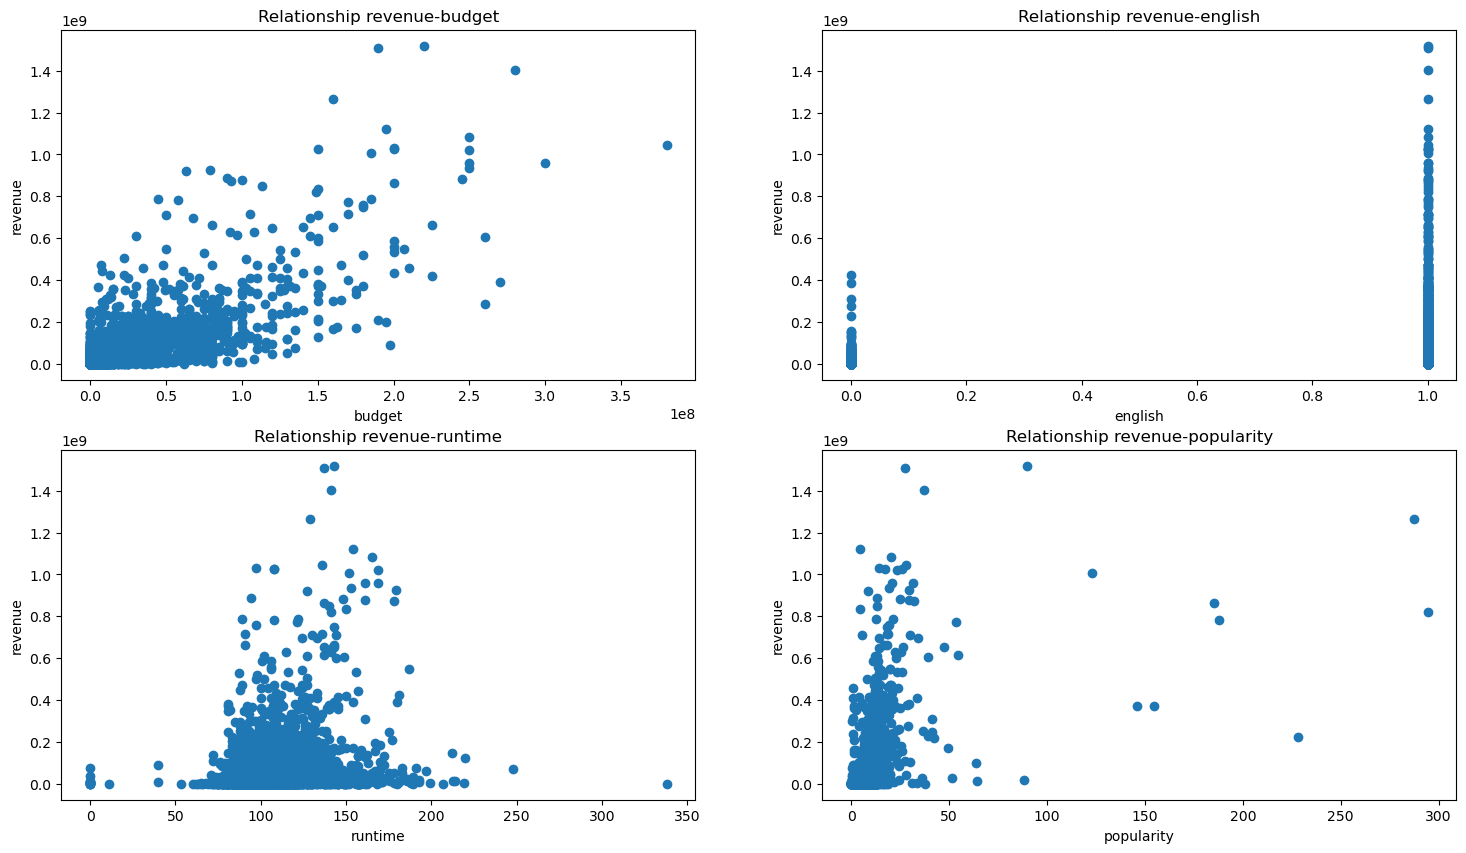

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

# Read in my data
movies = pd.read_csv("movie_revenues.csv")

# Create Data Frame for 4 explanatory variables and revenue
explanatory_variables_revenue = pd.DataFrame(movies, columns=["budget","original_language","runtime", "popularity",'revenue'])

# original language (the movie is english)
explanatory_variables_revenue['original_language']=explanatory_variables_revenue['original_language']=='en'
explanatory_variables_revenue = explanatory_variables_revenue.rename(columns={"original_language": "english"})

print('Ο πίνακας με τις 4 επεξηγηματικές μεταβλητές είναι:')
explanatory_variables = explanatory_variables_revenue[["budget","english","runtime", "popularity"]]
print(explanatory_variables)

# Compute the correlation coefficient
correlation = explanatory_variables_revenue.corr()
print('\nO συντελεστής συσχέτισης του revenue με το budget είναι:', correlation['revenue'].iloc[0])
print('O συντελεστής συσχέτισης του revenue με το english είναι:', correlation['revenue'].iloc[1])
print('O συντελεστής συσχέτισης του revenue με το runtime είναι:', correlation['revenue'].iloc[2])
print('O συντελεστής συσχέτισης του revenue με το popularity είναι:', correlation['revenue'].iloc[3])

# Revenue
revenue = explanatory_variables_revenue["revenue"]

# Scatter plot
fig = plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.scatter(explanatory_variables_revenue['budget'],revenue)
plt.xlabel('budget')
plt.ylabel('revenue')
plt.title('Relationship revenue-budget')

plt.subplot(2, 2, 2) 
plt.scatter(explanatory_variables_revenue['english'],revenue)
plt.xlabel('english')
plt.ylabel('revenue')
plt.title('Relationship revenue-english')

plt.subplot(2, 2, 3) 
plt.scatter(explanatory_variables_revenue['runtime'],revenue)
plt.xlabel('runtime')
plt.ylabel('revenue')
plt.title('Relationship revenue-runtime')

plt.subplot(2, 2, 4) 
plt.scatter(explanatory_variables_revenue['popularity'],revenue)
plt.xlabel('popularity')
plt.ylabel('revenue')
plt.title('Relationship revenue-popularity')

plt.show()

## Exercise 2

You will now use multiple regression to predict movie revenue. You can use just the variables in Exercise 1 above, or you can construct additional features: For example, you could construct a binary variable encoding if Brad Pitt is in the cast, or a numerical variable that encodes the number of female actors in the film.

`a)` Briefly describe your analysis (no more than 2 paragraphs). Did you include additional variables, and, if so, which one? What is the R2 of the model?

`b)` Are the conditions for the multiple linear regression model satisfied? Explain your answer

`c)` What is the slope associated with the variable you identified as most predictive in Exercise 1 above?

`d)` Which variables are significant for predicting movie revenue?


        revenue    budget  popularity  men  companies
0      12314651  14000000    6.575393   10          3
1      95149435  40000000    8.248895   10          1
2      13092000   3300000   64.299990   13          3
3      16000000   1200000    3.174936    2          0
4       3923970         0    1.148070    4          0
...         ...       ...         ...  ...        ...
2995    1596687         0    9.853270   11          2
2996     180590         0    3.727996    1          2
2997   89456761  65000000   14.482345    9          3
2998  171963386  42000000   15.725542   16          2
2999   82087155  35000000   10.512109   19          6

[3000 rows x 5 columns]
             revenue    budget  popularity       men  companies
revenue     1.000000  0.752965    0.461460  0.372587   0.155700
budget      0.752965  1.000000    0.342356  0.401443   0.253386
popularity  0.461460  0.342356    1.000000  0.267670   0.155638
men         0.372587  0.401443    0.267670  1.000000   0.172590
compani

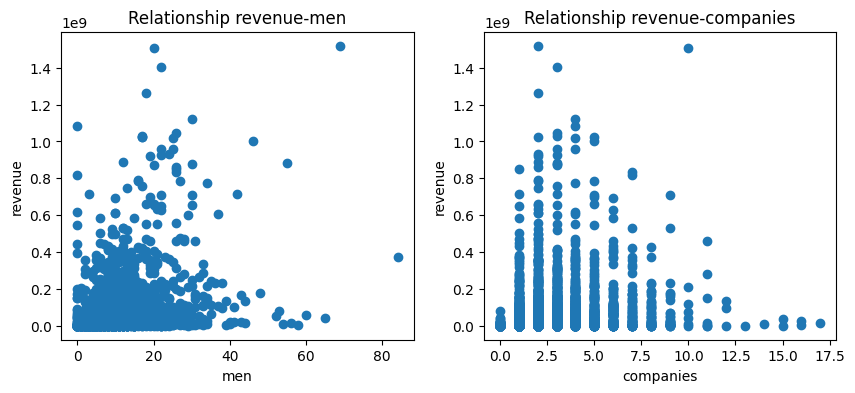

In [3]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Read in my data
movies = pd.read_csv("movie_revenues.csv")

# Create variables for regression
# Count men cast for each movie 
arr_men = np.zeros(len(movies), int)
for j in range(len(movies)):
    if pd.isna(movies['cast'].iloc[j]):
        continue
    cast = eval(movies['cast'].iloc[j])
    men = 0 
    for i in range(len(cast)):
        if cast[i]['gender'] == 2 : 
           men = men + 1 
    arr_men[j] = men

# Count production companies for each movie
arr_companies = np.zeros(len(movies), int)
for i in range(len(movies)):
    if pd.isna(movies['production_companies'].iloc[i]):
        continue
    companies = len(eval(movies['production_companies'].iloc[i]))
    arr_companies[i]=companies

# Create DataFrame with some variables
variables_regression = pd.DataFrame(movies, columns=["revenue","budget","popularity"])
variables_regression['men'] = arr_men
variables_regression['companies'] = arr_companies
print(variables_regression)

# Compute the correlation coefficient
print(variables_regression.corr())
print('\nO συντελεστής συσχέτισης του revenue με το men είναι:', variables_regression.revenue.corr(variables_regression.men))
print('O συντελεστής συσχέτισης του revenue με το companies είναι:', variables_regression.revenue.corr(variables_regression.companies))

revenue = variables_regression["revenue"]

fig = plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(variables_regression['men'],revenue)
plt.xlabel('men')
plt.ylabel('revenue')
plt.title('Relationship revenue-men')

plt.subplot(1, 2, 2)
plt.scatter(variables_regression['companies'],revenue)
plt.xlabel('companies')
plt.ylabel('revenue')
plt.title('Relationship revenue-companies')

plt.savefig("plot.png")
plt.show()


In [4]:
# Linear Regression
# use best 4 variables (according to correlation)
x = variables_regression[['budget', 'popularity', 'men', 'companies']]
y = variables_regression['revenue']

# model initialization
mlinear_model = LinearRegression()

# fit the data
mlinear_model.fit(x, y)
print('Slope:', mlinear_model.coef_)
print('Intercept:', mlinear_model.intercept_)

# predict
y_model = mlinear_model.intercept_ + mlinear_model.coef_[0] * x['budget'] + mlinear_model.coef_[1] * x['popularity'] + mlinear_model.coef_[2] * x['men'] + mlinear_model.coef_[3] * x['companies']
print('R-squared:', r2_score(y_model, y))

Slope: [ 2.48287008e+00  2.58367158e+06  9.96693078e+05 -3.97996983e+06]
Intercept: -9629084.210427262
R-squared: 0.3846796377596178


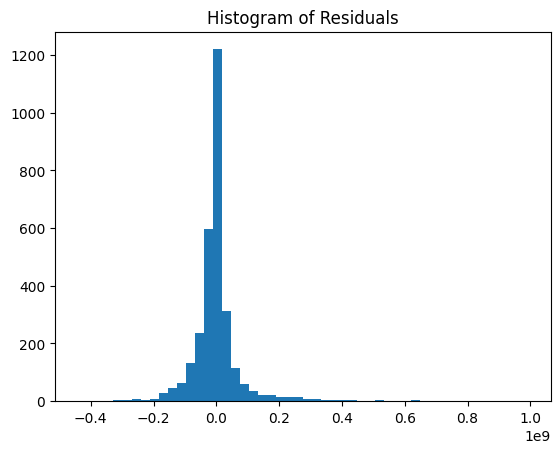

In [6]:
# calculate residuals
residuals = y - y_model
plt.hist(residuals, 50)
plt.title('Histogram of Residuals')
plt.savefig("hist.png")
plt.show()